In [1]:
import os

# Fix TF/protobuf runtime crash seen in this environment:
# Must be set BEFORE importing tensorflow.
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

import numpy as np
import pandas as pd

from PIL import Image
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers

BASE_DIR = "../input/aerial-cactus-identification"
if not os.path.exists(BASE_DIR):
    BASE_DIR = "../input"

print("Using BASE_DIR:", BASE_DIR)
print("Top-level ../input contents:", os.listdir("../input")[:20])

np.random.seed(42)
tf.random.set_seed(42)



2026-01-10 22:52:10.173119: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768085530.186735      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768085530.190994      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-10 22:52:10.208769: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Using BASE_DIR: ../input/aerial-cactus-identification
Top-level ../input contents: ['sample_submission.csv', 'description.md', 'test.zip', 'train.csv', 'sample_submission.csv.zip', 'test', 'train.zip', 'aerial-cactus-identification', 'train', 'train.csv.zip']


In [2]:
TRAIN_CSV = os.path.join(BASE_DIR, "train.csv")
SAMPLE_SUB = os.path.join(BASE_DIR, "sample_submission.csv")

train_dir_candidates = [
    os.path.join(BASE_DIR, "train", "train"),
    os.path.join(BASE_DIR, "train"),
]
test_dir_candidates = [
    os.path.join(BASE_DIR, "test", "test"),
    os.path.join(BASE_DIR, "test"),
]


def pick_existing_dir_with_csv_match(cands, csv_path):
    """Pick the first candidate directory that exists AND contains at least one file from csv 'id' column."""
    df_local = pd.read_csv(csv_path)
    ids = df_local["id"].values[:50]  # small probe
    existing = [d for d in cands if os.path.isdir(d)]
    if not existing:
        raise FileNotFoundError(f"No directory found among candidates: {cands}")
    for d in existing:
        if all(
            os.path.isfile(os.path.join(d, ids[i])) for i in range(min(5, len(ids)))
        ):
            return d
    best_d, best_hits = existing[0], -1
    for d in existing:
        hits = sum(os.path.isfile(os.path.join(d, x)) for x in ids)
        if hits > best_hits:
            best_d, best_hits = d, hits
    return best_d


def pick_existing_dir_with_jpgs(cands, min_jpgs=1):
    """Pick the first existing directory that actually contains jpg images (avoids empty nested folders)."""
    existing = [d for d in cands if os.path.isdir(d)]
    if not existing:
        raise FileNotFoundError(f"No directory found among candidates: {cands}")
    for d in existing:
        try:
            jpgs = [f for f in os.listdir(d) if f.lower().endswith(".jpg")]
        except Exception:
            jpgs = []
        if len(jpgs) >= min_jpgs:
            return d
    # fallback: choose the dir with most jpgs
    best_d, best_cnt = existing[0], -1
    for d in existing:
        try:
            cnt = sum(1 for f in os.listdir(d) if f.lower().endswith(".jpg"))
        except Exception:
            cnt = 0
        if cnt > best_cnt:
            best_d, best_cnt = d, cnt
    return best_d


data_dir = pick_existing_dir_with_csv_match(train_dir_candidates, TRAIN_CSV)
test_dir = pick_existing_dir_with_jpgs(test_dir_candidates, min_jpgs=1)

print("TRAIN_CSV:", TRAIN_CSV)
print("SAMPLE_SUB:", SAMPLE_SUB)
print("data_dir:", data_dir)
print("test_dir:", test_dir)



TRAIN_CSV: ../input/aerial-cactus-identification/train.csv
SAMPLE_SUB: ../input/aerial-cactus-identification/sample_submission.csv
data_dir: ../input/aerial-cactus-identification/train
test_dir: ../input/aerial-cactus-identification/test


In [3]:
df = pd.read_csv(TRAIN_CSV)
df.head(10)



,id,has_cactus
0,2de8f189f1dce439766637e75df0ee27.jpg,1
1,36704d250f236238e7f996812c48235d.jpg,1
2,eacde22fdc8c175972a5768e3daa8bc9.jpg,1
3,5d442f834da5e57d22b24802c32a8ca8.jpg,1
4,152491e0daf75c0e669400300ff7e645.jpg,1
5,7aea2cdb1333f960d3ffd0eb4889ad7f.jpg,1
6,c096417915f70c41b2a2ff732bf63e6b.jpg,1
7,924345ef46d9772e9a8adb4920c1e65c.jpg,1
8,f919c1bc54e15203575d90a2b2e72a04.jpg,1
9,832654dea6e6d520715cd80911a50e1c.jpg,1


In [4]:
print("Test dir listing (first 10):", sorted(os.listdir(test_dir))[:10])
print("Train dir listing (first 10):", sorted(os.listdir(data_dir))[:10])



Test dir listing (first 10): ['002930423b9840e67e5a54afd4768a1e.jpg', '00351838ebf6dff6e53056e00a1e307c.jpg', '003ec9bcef67171ba49fe4c3b7c80aec.jpg', '0051207eb794887c619341090de84b50.jpg', '0057728c8522c4881af60c3105b6492e.jpg', '008fa43d2e3c2354fc174d22a12a2055.jpg', '009350e896ad5c23456ce7697d4de276.jpg', '009eead3ac74832bc9822f3342d97fce.jpg', '00ba3da3fe6d600703e28dece68fbb12.jpg', '00be32b57f411d75293bb7234aabeb58.jpg']
Train dir listing (first 10): ['0004be2cfeaba1c0361d39e2b000257b.jpg', '000c8a36845c0208e833c79c1bffedd1.jpg', '000d1e9a533f62e55c289303b072733d.jpg', '0011485b40695e9138e92d0b3fb55128.jpg', '0014d7a11e90b62848904c1418fc8cf2.jpg', '0017c3c18ddd57a2ea6f9848c79d83d2.jpg', '002134abf28af54575c18741b89dd2a4.jpg', '0024320f43bdd490562246435af4f90b.jpg', '003519dd841a97ed16481fa0657df04d.jpg', '003bb64852016d9c87871ddd8e25ab03.jpg']


In [5]:
filename = df["id"].iloc[0]
path = os.path.join(data_dir, filename)
print("Example train image path:", path)
image_pil = Image.open(path)
image_pil.size



Example train image path: ../input/aerial-cactus-identification/train/2de8f189f1dce439766637e75df0ee27.jpg


(32, 32)

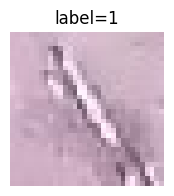

In [6]:
image = np.array(image_pil)
plt.figure(figsize=(2, 2))
plt.title(f"label={df['has_cactus'].iloc[0]}")
plt.imshow(image)
plt.axis("off")
plt.show()



In [7]:
print("Positive rate:", float(np.mean(df["has_cactus"])))
print("Pos/Total:", int(np.sum(df["has_cactus"])), "/", len(df["has_cactus"]))
print("Image shape/min/max:", image.shape, np.min(image), np.max(image))




Positive rate: 0.7497707231040565
Pos/Total: 10628 / 14175
Image shape/min/max: (32, 32, 3) 69 255


In [8]:
def get_data(pathtuple):
    path, label = pathtuple
    if not os.path.isfile(path):
        raise FileNotFoundError(f"Missing image file: {path}")
    image_pil = Image.open(path)
    image = np.array(image_pil).astype(np.float32) / 255.0
    label = tf.keras.utils.to_categorical(label, 2).astype(np.float32)
    return image, label




In [9]:
train_filenames = []
missing_train = 0
for i, fname in enumerate(df["id"].values):
    full_path = os.path.join(data_dir, fname)
    if not os.path.isfile(full_path):
        missing_train += 1
        continue
    train_filenames.append((full_path, int(df["has_cactus"].iloc[i])))

test_filenames = [f for f in os.listdir(test_dir) if f.lower().endswith(".jpg")]
test_filenames = sorted(test_filenames)

test_arr = []
for testfilename in test_filenames:
    path = os.path.join(test_dir, testfilename)
    image_pil = Image.open(path)
    image = np.array(image_pil).astype(np.float32) / 255.0
    test_arr.append(image)

test_data = np.array(test_arr, dtype=np.float32)

print("Train samples:", len(train_filenames), "(missing skipped:", missing_train, ")")
print("Test samples:", len(test_filenames))
print("Test data shape:", test_data.shape)




Train samples: 14175 (missing skipped: 0 )
Test samples: 3325
Test data shape: (3325, 32, 32, 3)


In [10]:
def make_batch(batch_paths):
    batch_images = []
    batch_labels = []
    for pathtuple in batch_paths:
        img, lbl = get_data(pathtuple)
        batch_images.append(img)
        batch_labels.append(lbl)
    return np.array(batch_images, dtype=np.float32), np.array(
        batch_labels, dtype=np.float32
    )




In [11]:
batch_size = 32


def data_gen(data_paths, is_training=True):
    global_step = 0
    steps_per_epoch = max(1, len(data_paths) // batch_size)  # prevent 0 which can crash
    while True:
        step = global_step % steps_per_epoch
        if step == 0 and is_training:
            np.random.shuffle(data_paths)
        sl = slice(step * batch_size, (step + 1) * batch_size)
        batch = data_paths[sl]
        if len(batch) == 0:
            batch = data_paths[:batch_size]
        images, labels = make_batch(batch)
        global_step += 1
        yield images, labels




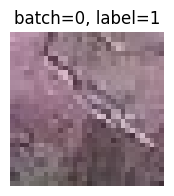

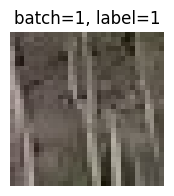

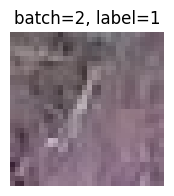

In [12]:
gen = data_gen(train_filenames)
for i, (img, lbl) in enumerate(gen):
    if i >= 3:
        break
    plt.figure(figsize=(2, 2))
    plt.title(f"batch={i}, label={int(np.argmax(lbl[0]))}")
    plt.imshow(img[0])
    plt.axis("off")
    plt.show()



In [13]:
num_epochs = 20
learning_rate = 0.001
num_classes = 2
input_shape = (32, 32, 3)



In [14]:
inputs = layers.Input(input_shape)
net = layers.Conv2D(64, (3, 3), padding="same")(inputs)
net = layers.Conv2D(64, (3, 3), padding="same")(net)
net = layers.Conv2D(64, (3, 3), padding="same")(net)
net = layers.BatchNormalization()(net)
net = layers.Activation("relu")(net)
net = layers.MaxPooling2D(pool_size=(2, 2))(net)

net = layers.Conv2D(128, (3, 3), padding="same")(net)
net = layers.Conv2D(128, (3, 3), padding="same")(net)
net = layers.Conv2D(128, (3, 3), padding="same")(net)
net = layers.BatchNormalization()(net)
net = layers.Activation("relu")(net)
net = layers.MaxPooling2D(pool_size=(2, 2))(net)
net = layers.Dropout(0.25)(net)

net = layers.Conv2D(256, (3, 3), padding="same")(net)
net = layers.Conv2D(256, (3, 3), padding="same")(net)
net = layers.Conv2D(256, (3, 3), padding="same")(net)
net = layers.BatchNormalization()(net)
net = layers.Activation("relu")(net)
net = layers.MaxPooling2D(pool_size=(2, 2))(net)
net = layers.Dropout(0.25)(net)

net = layers.Conv2D(512, (3, 3), padding="same")(net)
net = layers.Conv2D(512, (3, 3), padding="same")(net)
net = layers.Conv2D(512, (3, 3), padding="same")(net)
net = layers.BatchNormalization()(net)
net = layers.Activation("relu")(net)
net = layers.MaxPooling2D(pool_size=(2, 2))(net)
net = layers.Dropout(0.25)(net)

net = layers.Conv2D(512, (3, 3), padding="same")(net)
net = layers.Conv2D(512, (3, 3), padding="same")(net)
net = layers.Conv2D(512, (3, 3), padding="same")(net)
net = layers.BatchNormalization()(net)
net = layers.Activation("relu")(net)
net = layers.MaxPooling2D(pool_size=(2, 2))(net)
net = layers.Dropout(0.25)(net)

net = layers.Flatten()(net)
net = layers.Dense(512)(net)
net = layers.Activation("relu")(net)
net = layers.Dropout(0.5)(net)
net = layers.Dense(num_classes)(net)
net = layers.Activation("softmax")(net)

model = tf.keras.Model(inputs=inputs, outputs=net)



2026-01-10 22:52:18.537503: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1768085538.537956      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:45:00.0, compute capability: 8.6


In [15]:
model.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate),
    metrics=["accuracy"],
)

model.summary()



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 15,168,770 (57.86 MB)

 Trainable params: 15,165,826 (57.85 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [16]:
steps_per_epoch = max(1, len(train_filenames) // batch_size)

history = model.fit(
    data_gen(train_filenames, is_training=True),
    steps_per_epoch=steps_per_epoch,
    epochs=num_epochs,
    verbose=1,
)



Epoch 1/20


I0000 00:00:1768085544.700937      64 service.cc:148] XLA service 0x7fec280027c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768085544.700980      64 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-01-10 22:52:24.779945: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1768085545.198828      64 cuda_dnn.cc:529] Loaded cuDNN version 90300


 13/442 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6018 - loss: 1.3432

I0000 00:00:1768085550.000870      64 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


442/442 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.8576 - loss: 0.3379
Epoch 2/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9725 - loss: 0.0791
Epoch 3/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9793 - loss: 0.0608
Epoch 4/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9799 - loss: 0.0549
Epoch 5/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9837 - loss: 0.0484
Epoch 6/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9877 - loss: 0.0348
Epoch 7/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9885 - loss: 0.0350
Epoch 8/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9879 - loss: 0.0342
Epoch 9/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9906 - loss: 0.0242
Epoch 10/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9932 - loss: 0.0166
Epoch 11/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9943 - loss: 0.0182
Epoch 12/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/st

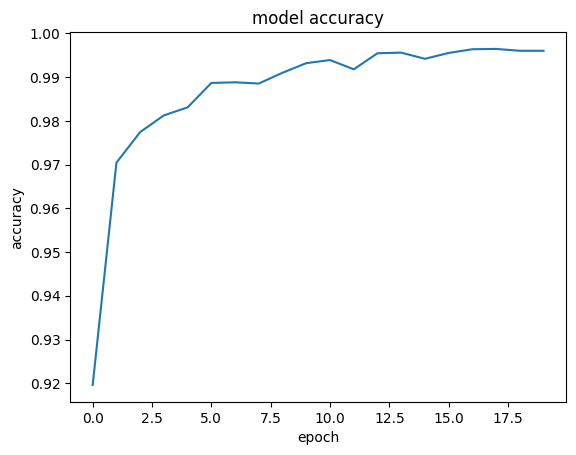

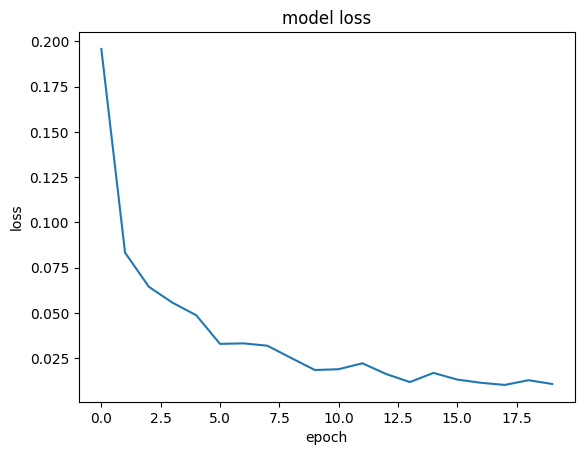

In [17]:
acc_key = (
    "accuracy"
    if "accuracy" in history.history
    else ("acc" if "acc" in history.history else None)
)
loss_key = "loss"

if acc_key is not None:
    plt.plot(history.history[acc_key])
    plt.title("model accuracy")
    plt.ylabel("accuracy")
    plt.xlabel("epoch")
    plt.show()

plt.plot(history.history[loss_key])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.show()



In [18]:
if test_data.shape[0] == 0:
    raise RuntimeError(
        f"No test images found/loaded from: {test_dir}. "
        f"Candidates were: {test_dir_candidates}. BASE_DIR={BASE_DIR}"
    )

pred_probs = model.predict(test_data, batch_size=256, verbose=1)
has_cactus_prob = pred_probs[:, 1].astype(np.float32)

print("Pred probs shape:", pred_probs.shape)
print(
    "Submission prob stats:",
    float(has_cactus_prob.min()),
    float(has_cactus_prob.max()),
    float(has_cactus_prob.mean()),
)



13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step
Pred probs shape: (3325, 2)
Submission prob stats: 1.44053174722103e-07 1.0 0.7510125637054443


In [19]:
submission = pd.DataFrame({"id": test_filenames, "has_cactus": has_cactus_prob})

# Ensure exact expected ordering/IDs by aligning to sample_submission if available
if os.path.isfile(SAMPLE_SUB):
    sample = pd.read_csv(SAMPLE_SUB)
    submission = sample[["id"]].merge(submission, on="id", how="left")
    if submission["has_cactus"].isna().any():
        missing = int(submission["has_cactus"].isna().sum())
        raise RuntimeError(
            f"{missing} submission rows could not be matched to predictions. Check test_dir/id alignment."
        )

submission_path = "submission.csv"
submission.to_csv(submission_path, index=False)

print("Wrote:", submission_path)
print(submission.head())
print("Rows:", len(submission), "Expected:", len(test_filenames))

Wrote: submission.csv
                                     id  has_cactus
0  09034a34de0e2015a8a28dfe18f423f6.jpg         1.0
1  134f04305c795d6d202502c2ce3578f3.jpg         1.0
2  41fad8d145e6c41868ce3617e30a2545.jpg         1.0
3  35f8a11352c8d41b6231bb33d8d09f7e.jpg         1.0
4  b77dc902b035887cbbc01920ce0e3151.jpg         1.0
Rows: 3325 Expected: 3325
